# Création d'un jeu de donnée pour le tp 
- series normales (label = 0)
- series anormales (label = 1)
- tous les points sont pris dans le même intervalle de temps (1-10), mais la frequence d'échantillonage peut varier d'une série à une autre

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import scipy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score

def random_ts(mean, base_freq, base_noise):
    points = np.linspace(1,10,100+np.random.randint(10))
    f_cos = base_freq*np.random.randint(10)-5
    f_sin = base_freq*np.random.randint(10)-5
    noise = base_noise* np.random.rand(len(points))
    return f_cos*np.cos(points)+f_sin*np.sin(points)+noise

data_normal = [random_ts(1, 1, 3) for i in range(700)]
data_ano = [random_ts(1.05, 1.3, 3.5) for i in range(300)]
labels = [1]*700 + [0]*300
data = data_normal+data_ano

def train_and_eval(data, labels):
    x_train, x_val, y_train, y_val = train_test_split(data,labels)
    clf = RandomForestClassifier()
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_val)
    print("\tPrecision: %1.3f" % precision_score(y_val, y_pred))
    print("\tRecall: %1.3f" % recall_score(y_val, y_pred))

- regardons les echantillons :

In [28]:
len(data[0])

108

<Axes: >

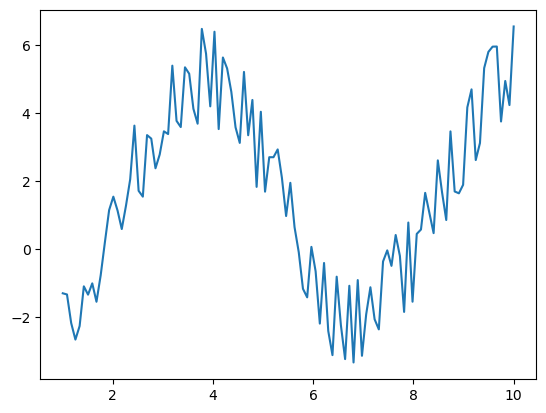

In [29]:
points = np.linspace(1,10,len(data[0]))
sns.lineplot(x=points, y=data[0])

In [30]:
len(data[1])

106

<Axes: >

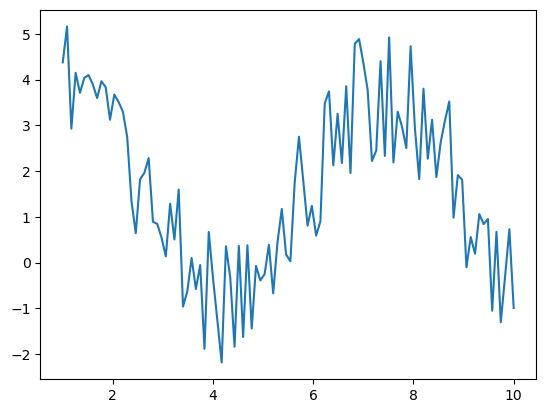

In [31]:
points = np.linspace(1,10,len(data[1]))
sns.lineplot(x=points, y=data[1])

- le nombre de points varie légerement entre les séries, et donc le temps d'acquisition de chaque valeur de la série temporelle comme la frequence d'échantillonage reste constante

### Interpolation linéaire

on veut ramener tous les échantillon à 100 points, comme c'est le nombre de point de la plus petite TS du jeu de donnée

In [32]:
interpolation_times =  np.linspace(1,10,100) # les points du temps ou l'on veut interpoler

interpolated_data = list()
for ts in data:
    original_ts_time = np.linspace(1,10,len(ts))
    interpolation_function = scipy.interpolate.interp1d(original_ts_time, ts) # genere la fonction d'interpolation
    interpolated_values = interpolation_function(interpolation_times) # obtient les valeurs aux instants que l'on souhaite
    interpolated_data.append(interpolated_values)

In [33]:
len(interpolated_data)

1000

In [34]:
len(interpolated_data[1])

100

- on s'est bien ramené à un jeu de donnée "homogene", constitué de series temporelles
    - ayant un meme nombre de point
    - interpolées au mêmes instants (ceux d'interpolation_times)

In [35]:
train_and_eval(interpolated_data, labels)

	Precision: 0.800
	Recall: 0.983


### Extraction d'indicateurs simples

- creer des features simples : moyenne, std, max, min

In [36]:
sample_mean = np.array([np.mean(ts) for ts in interpolated_data])
sample_std = np.array([np.std(ts) for ts in interpolated_data])
sample_max = np.array([np.max(ts) for ts in interpolated_data])
sample_min = np.array([np.min(ts) for ts in interpolated_data])

In [37]:
featured_data = np.zeros((1000,4))
featured_data[:,0] =sample_mean 
featured_data[:,1] =sample_std 
featured_data[:,2] =sample_max 
featured_data[:,3] =sample_min 

- Verifions l'interet de nos features :

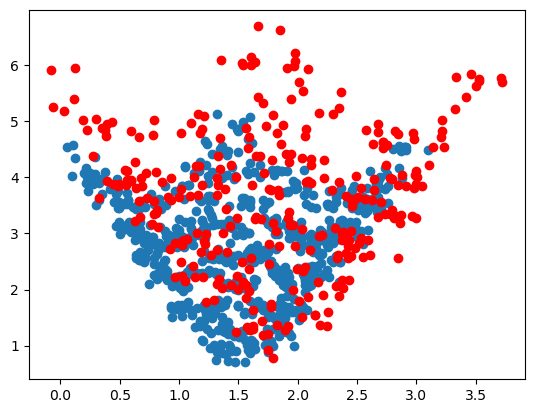

In [38]:
plt.scatter(sample_mean[np.array(labels)==1], sample_std[np.array(labels)==1])
plt.scatter(sample_mean[np.array(labels)==0], sample_std[np.array(labels)==0], color='red')
plt.show()

In [39]:
train_and_eval(featured_data, labels)

	Precision: 0.897
	Recall: 0.954


### PCA

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(interpolated_data)

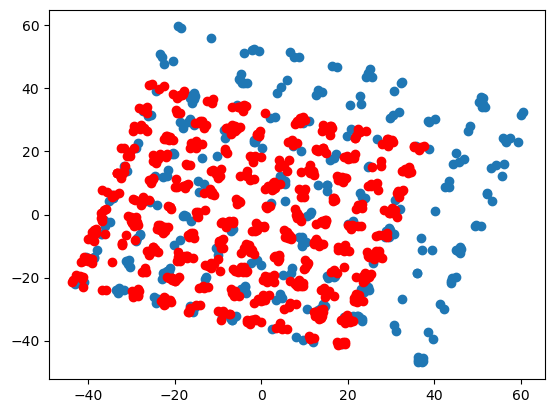

In [41]:
plt.scatter(pca_data[:,0][np.array(labels)==0], pca_data[:,1][np.array(labels)==0])
plt.scatter(pca_data[:,0][np.array(labels)==1], pca_data[:,1][np.array(labels)==1], color='red')
plt.show()

- ça a l'air mieux
- quel drole de motif, un quadrillage de taille 10 alors que j'ai généré les données avec des randints prenant 10 valeurs possibles !

In [42]:
train_and_eval(pca_data, labels)

	Precision: 0.826
	Recall: 0.954


- c'est mieux !

### FFT

In [43]:
from scipy.fft import fft
fft_data = np.array([np.abs(fft(ts))[:50] for ts in interpolated_data])
fft_data = fft_data/np.mean(fft_data, axis=0)

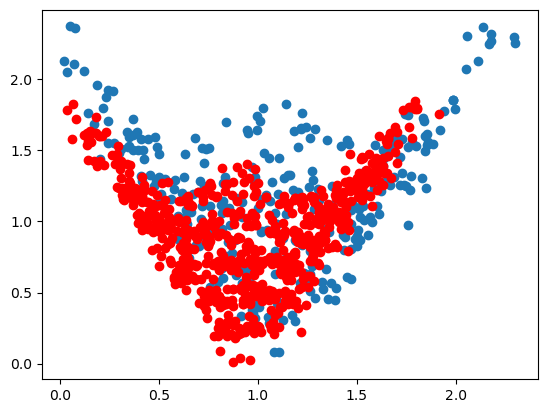

In [44]:
plt.scatter(fft_data[:,0][np.array(labels)==0], fft_data[:,1][np.array(labels)==0])
plt.scatter(fft_data[:,0][np.array(labels)==1], fft_data[:,1][np.array(labels)==1], color='red')
plt.show()

In [45]:
train_and_eval(fft_data, labels)

	Precision: 0.807
	Recall: 0.949


- c'est moins bien !

In [46]:
concat_data = np.column_stack((sample_mean, sample_std, sample_max, sample_min))

In [47]:
train_and_eval(concat_data, labels)

	Precision: 0.887
	Recall: 0.943


- mais cela apporte quand même ajouté à la pca simple !

## Les wavelets

In [48]:
from scipy.signal import cwt
from scipy import signal
widths = np.arange(1,30)
wavelet_data = np.array([np.abs(signal.cwt(x, signal.morlet2, widths)) for x in interpolated_data])
wavelet_data = wavelet_data/np.mean(wavelet_data)

C:\Users\benoi\AppData\Local\Temp\ipykernel_8712\830095149.py:4: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  wavelet_data = np.array([np.abs(signal.cwt(x, signal.morlet2, widths)) for x in interpolated_data])


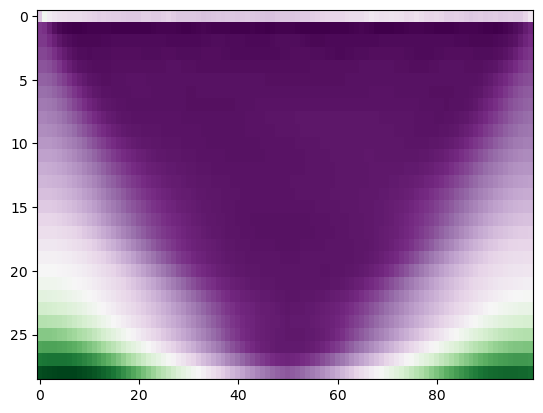

In [56]:
plt.imshow(np.mean(wavelet_data[np.array(labels)==0],axis=0), cmap='PRGn', aspect='auto')

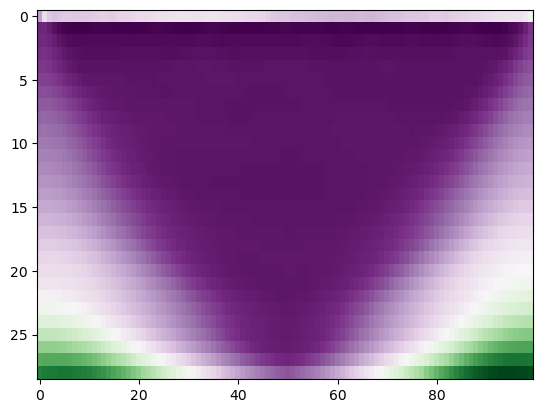

In [57]:
plt.imshow(np.mean(wavelet_data[np.array(labels)==1],axis=0), cmap='PRGn',aspect='auto')

- la difference a l'air plus flagrante "en bas"

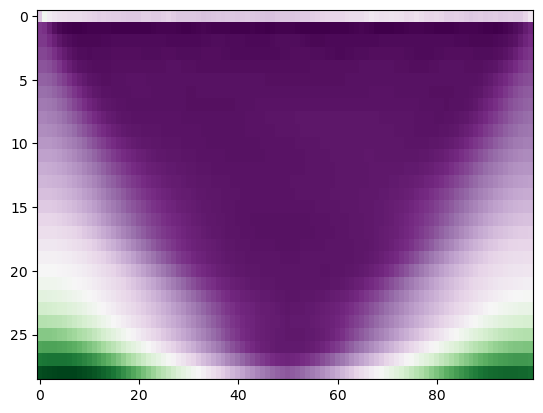

In [58]:
plt.imshow(np.mean(wavelet_data[np.array(labels)==0],axis=0), cmap='PRGn', aspect='auto')

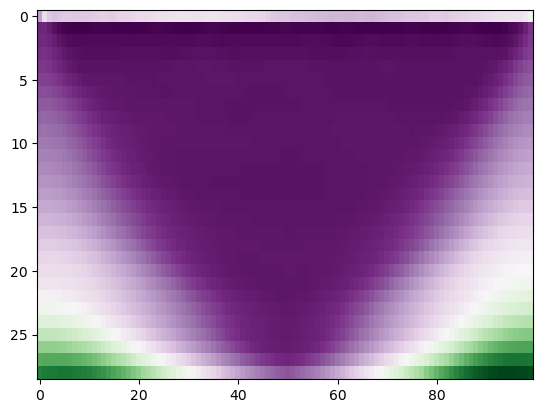

In [59]:
plt.imshow(np.mean(wavelet_data[np.array(labels)==1],axis=0), cmap='PRGn',aspect='auto')

In [64]:
wavelet_data_max = np.max(wavelet_data.reshape(wavelet_data.shape[0], -1), axis=1)
wavelet_data_mean = np.mean(wavelet_data.reshape(wavelet_data.shape[0], -1), axis=1)
wavelet_data_std = np.std(wavelet_data.reshape(wavelet_data.shape[0], -1), axis=1)
wavelet_data_min = np.min(wavelet_data.reshape(wavelet_data.shape[0], -1), axis=1)

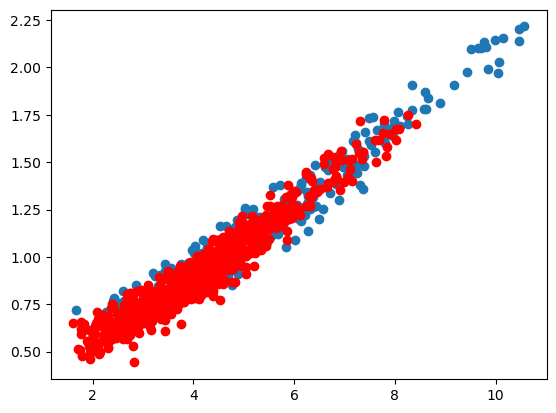

In [66]:
plt.scatter(wavelet_data_max[:][np.array(labels)==0], wavelet_data_mean[:][np.array(labels)==0])
plt.scatter(wavelet_data_max[:][np.array(labels)==1], wavelet_data_mean[:][np.array(labels)==1], color='red')
plt.show()

In [67]:
wave_data = np.zeros((1000,4))
wave_data[:,0] =wavelet_data_max
wave_data[:,1] =wavelet_data_mean
wave_data[:,2] =wavelet_data_min
wave_data[:,3] =wavelet_data_std
train_and_eval(wave_data, labels)

	Precision: 0.693
	Recall: 0.904


- moins interessant que l'approche fft

In [68]:
pca_wave = PCA(n_components=2).fit_transform(wave_data)

In [69]:
train_and_eval(pca_wave, labels)

	Precision: 0.816
	Recall: 0.838


- un peu mieux avec une pca

In [70]:
concat_data = np.column_stack((pca_wave, sample_mean, sample_std, sample_max, sample_min))

In [71]:
train_and_eval(concat_data, labels)

	Precision: 0.830
	Recall: 0.960


- redondant avec la fft

# Et pour aller plus loin ?:
- creuser davantage les paramètres de chaques methodes et les combinaisons de features
- selection automatique des meilleures features, ... 
- ts_fresh
- changer le modèle
- utilisation de réseaux de neurones (convolution, lstm)

In [73]:
from sklearn.metrics import accuracy_score

# Résumé de tous les résultats
resultats = {
    'Méthode': [
        'Données brutes interpolées',
        'Features simples (mean, std, max, min)',
        'PCA (2 composantes)',
        'FFT (50 composantes)',
        'Wavelets (statistiques)',
        'Wavelets + PCA',
        'Wavelets + PCA + Features simples'
    ],
    'Dataset': [
        interpolated_data,
        featured_data,
        pca_data,
        fft_data,
        wave_data,
        pca_wave,
        concat_data
    ]
}

print("\n" + "="*70)
print("RÉSUMÉ COMPARATIF DE TOUTES LES MÉTHODES")
print("="*70 + "\n")

for i, (nom, data) in enumerate(zip(resultats['Méthode'], resultats['Dataset'])):
    x_train, x_val, y_train, y_val = train_test_split(data, labels)
    clf = RandomForestClassifier(random_state=42)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_val)
    
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    
    print(f"{i+1}. {nom}")
    print(f"   Precision: {precision:.3f} | Recall: {recall:.3f} | Accuracy: {accuracy:.3f}\n")

print("="*70)
print("Conclusion: La meilleure méthode combine [À voir selon les résultats]")
print("="*70)


RÉSUMÉ COMPARATIF DE TOUTES LES MÉTHODES

1. Données brutes interpolées
   Precision: 0.788 | Recall: 0.983 | Accuracy: 0.800

2. Features simples (mean, std, max, min)
   Precision: 0.858 | Recall: 0.953 | Accuracy: 0.860

3. PCA (2 composantes)
   Precision: 0.839 | Recall: 0.928 | Accuracy: 0.820

4. FFT (50 composantes)
   Precision: 0.797 | Recall: 0.927 | Accuracy: 0.780

5. Wavelets (statistiques)
   Precision: 0.787 | Recall: 0.861 | Accuracy: 0.732

6. Wavelets + PCA
   Precision: 0.744 | Recall: 0.865 | Accuracy: 0.704

7. Wavelets + PCA + Features simples
   Precision: 0.878 | Recall: 0.938 | Accuracy: 0.864

Conclusion: La meilleure méthode combine [À voir selon les résultats]
